# Análisis Exploratorio de Datos: Palmer Penguins

El **Análisis Exploratorio de Datos (EDA)** es el primer paso en cualquier proyecto de minería de datos. Su objetivo es entender la estructura, distribución y relaciones en los datos **antes** de aplicar cualquier modelo.

En este notebook utilizaremos el dataset **Palmer Penguins**, una alternativa moderna al clásico Iris, que contiene mediciones de tres especies de pingüinos recolectadas en el Archipiélago Palmer, Antártida.

## Contenido

1. **Carga y primer vistazo**: Importar datos y entender su estructura
2. **Calidad de datos**: Identificar y tratar valores faltantes
3. **Análisis univariado**: Distribución de cada variable
4. **Análisis bivariado**: Relaciones entre pares de variables
5. **Análisis multivariado**: Patrones en múltiples dimensiones
6. **Clasificación**: Logística multinomial (aleta, masa y sexo)
7. **Clasificación con pico**: Mismo modelo añadiendo longitud del pico
8. **Conclusiones**: Síntesis de hallazgos

---

### El dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `species` | Categórica | Especie: Adelie, Chinstrap, Gentoo |
| `island` | Categórica | Isla: Biscoe, Dream, Torgersen |
| `bill_length_mm` | Numérica | Longitud del pico (mm) |
| `bill_depth_mm` | Numérica | Profundidad del pico (mm) |
| `flipper_length_mm` | Numérica | Longitud de la aleta (mm) |
| `body_mass_g` | Numérica | Masa corporal (g) |
| `sex` | Categórica | Sexo: male, female |

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)
*Ilustración: Allison Horst*

## 0. Configuración del entorno

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Estilo global
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Colores por especie (consistentes en todo el notebook)
COLORES_ESPECIE = {
    'Adelie':    '#E69F00',
    'Chinstrap': '#009E73',
    'Gentoo':    '#56B4E9',
}

np.random.seed(42)

## 1. Carga y primer vistazo

In [126]:
# seaborn incluye el dataset directamente
df = sns.load_dataset('penguins')

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones: 344 filas × 7 columnas


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [128]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,Male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observaciones iniciales:**
- El dataset tiene 344 registros y 7 columnas.
- Las variables numéricas son: longitud y profundidad del pico, longitud de aleta y masa corporal.
- Las variables categóricas son: especie, isla y sexo.
- Se observan algunos valores faltantes (`NaN`) que necesitamos cuantificar.

## 2. Calidad de datos

Antes de explorar, revisamos si los datos están completos y tienen sentido.

In [129]:
# Conteo y porcentaje de valores faltantes
faltantes = df.isnull().sum()
pct = (faltantes / len(df) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'Faltantes': faltantes,
    'Porcentaje (%)': pct
}).query('Faltantes > 0')

print('Variables con valores faltantes:')
print(resumen_faltantes.to_string())

Variables con valores faltantes:
                   Faltantes  Porcentaje (%)
bill_length_mm             2            0.58
bill_depth_mm              2            0.58
flipper_length_mm          2            0.58
body_mass_g                2            0.58
sex                       11            3.20


In [130]:
# Porcentaje de faltantes por especie (sobre el total de cada especie)
cols_con_faltantes = resumen_faltantes.index.tolist()
pct_por_especie = (
    df.set_index('species')[cols_con_faltantes]
      .isnull()
      .groupby(level=0)
      .mean()
      .mul(100)
      .round(2)
)

filas_incompletas = (
    df.assign(_incompleto=df.isnull().any(axis=1))
      .groupby('species')['_incompleto']
      .agg(Registros='size', Con_faltantes='sum')
)
filas_incompletas['Porcentaje (%)'] = (
    filas_incompletas['Con_faltantes'] / filas_incompletas['Registros'] * 100
).round(2)

print('Porcentaje de valores faltantes por especie:')
print(pct_por_especie.to_string())
print('\nRegistros incompletos por especie:')
print(filas_incompletas.to_string())

Porcentaje de valores faltantes por especie:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g   sex
species                                                                       
Adelie               0.66           0.66               0.66         0.66  3.95
Chinstrap            0.00           0.00               0.00         0.00  0.00
Gentoo               0.81           0.81               0.81         0.81  4.03

Registros incompletos por especie:
           Registros  Con_faltantes  Porcentaje (%)
species                                            
Adelie           152              6            3.95
Chinstrap         68              0            0.00
Gentoo           124              5            4.03


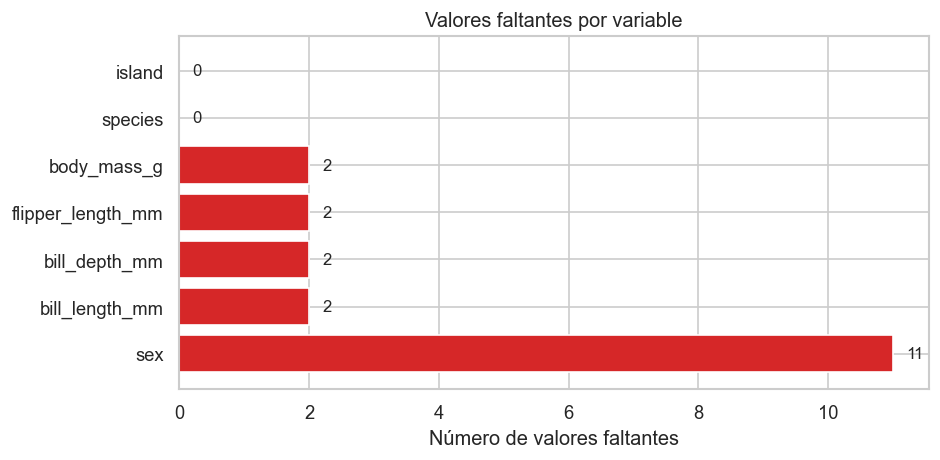

In [131]:
# Visualizar el patrón de valores faltantes
fig, ax = plt.subplots(figsize=(8, 4))

faltantes_plot = df.isnull().sum().sort_values(ascending=False)
colores = ['#d62728' if v > 0 else '#aec7e8' for v in faltantes_plot.values]

bars = ax.barh(faltantes_plot.index, faltantes_plot.values, color=colores)
ax.set_xlabel('Número de valores faltantes')
ax.set_title('Valores faltantes por variable')

for bar, val in zip(bars, faltantes_plot.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [132]:
# Identificar las filas con valores faltantes
df[df.isnull().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Los valores faltantes representan menos del 4% del total. Para el análisis exploratorio los eliminaremos para evitar distorsiones.

In [133]:
df_clean = df.dropna().reset_index(drop=True)
print(f'Registros originales : {len(df)}')
print(f'Registros tras limpiar: {len(df_clean)}')
print(f'Eliminados           : {len(df) - len(df_clean)}')

Registros originales : 344
Registros tras limpiar: 333
Eliminados           : 11


## 3. Análisis univariado

Estudiamos cada variable de forma individual para entender su distribución.

### 3.1 Variables categóricas

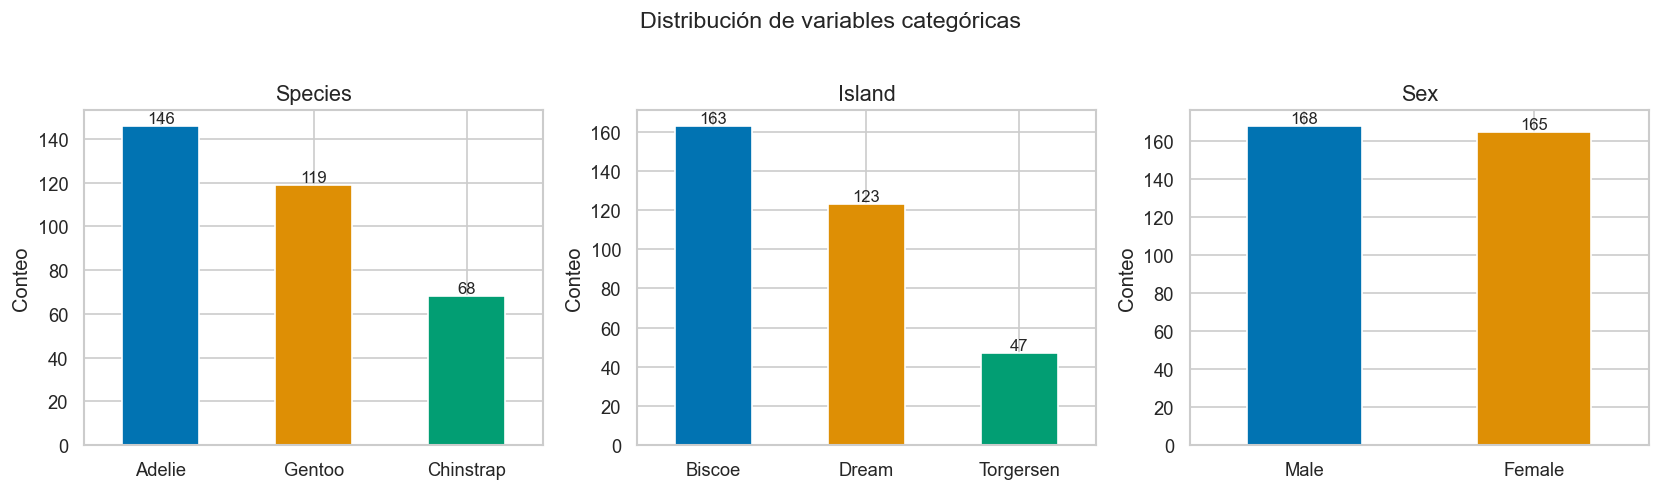

In [134]:
categoricas = ['species', 'island', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, categoricas):
    conteo = df_clean[col].value_counts()
    conteo.plot(kind='bar', ax=ax, color=sns.color_palette('colorblind', len(conteo)),
                edgecolor='white', rot=0)
    ax.set_title(col.capitalize(), fontsize=13)
    ax.set_ylabel('Conteo')
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

fig.suptitle('Distribución de variables categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos:**
- La especie **Adelie** es la más frecuente (≈44%), seguida por Gentoo (≈36%) y Chinstrap (≈20%).
- La isla **Dream** concentra la mayor cantidad de observaciones, seguida de Biscoe y Torgersen.
- La distribución por **sexo** es prácticamente balanceada.

### 3.2 Variables numéricas

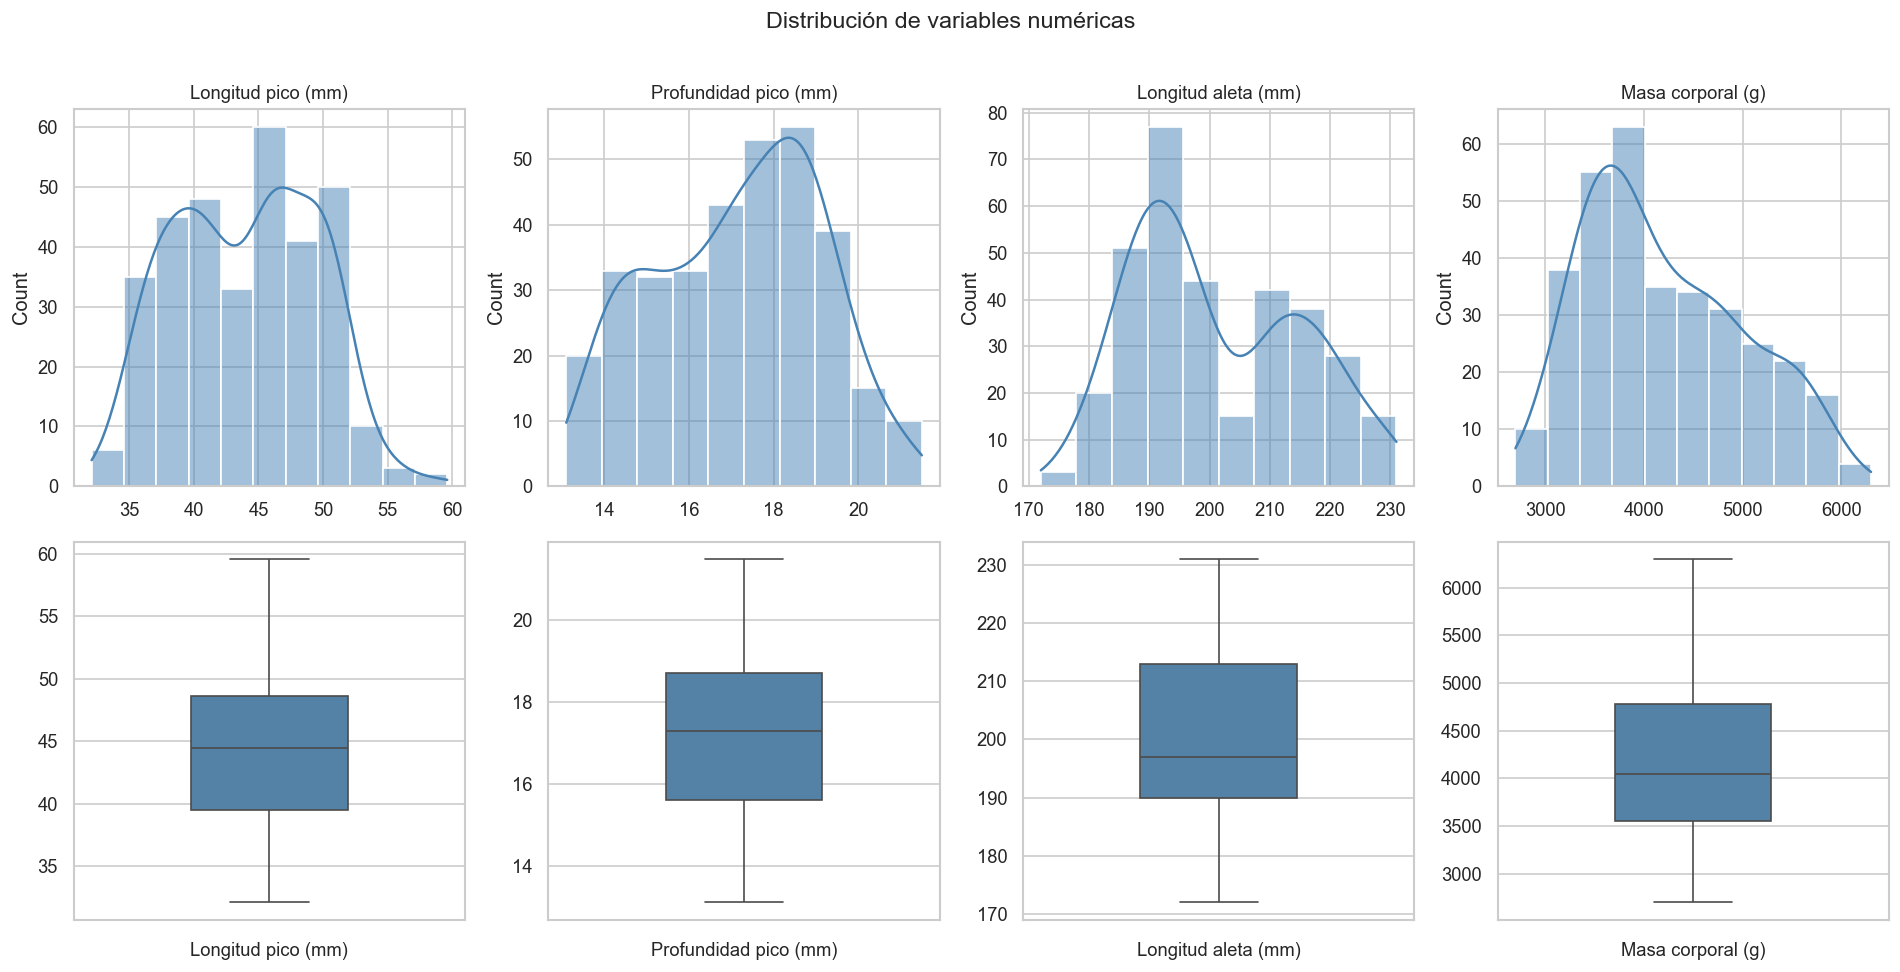

In [135]:
numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
etiquetas = ['Longitud pico (mm)', 'Profundidad pico (mm)', 'Longitud aleta (mm)', 'Masa corporal (g)']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, etiqueta) in enumerate(zip(numericas, etiquetas)):
    # Histograma + KDE
    ax_hist = axes[0, i]
    sns.histplot(df_clean[col], kde=True, ax=ax_hist,
                 color='steelblue', edgecolor='white')
    ax_hist.set_title(etiqueta, fontsize=11)
    ax_hist.set_xlabel('')

    # Boxplot
    ax_box = axes[1, i]
    sns.boxplot(y=df_clean[col], ax=ax_box, color='steelblue',
                width=0.4, flierprops={'marker': 'o', 'markersize': 5})
    ax_box.set_xlabel(etiqueta, fontsize=11)
    ax_box.set_ylabel('')

fig.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [136]:
# Estadísticas descriptivas
df_clean[numericas].describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00


## 4. Análisis bivariado

Exploramos las relaciones entre pares de variables, especialmente en función de la especie.

### 4.1 Correlación entre variables numéricas

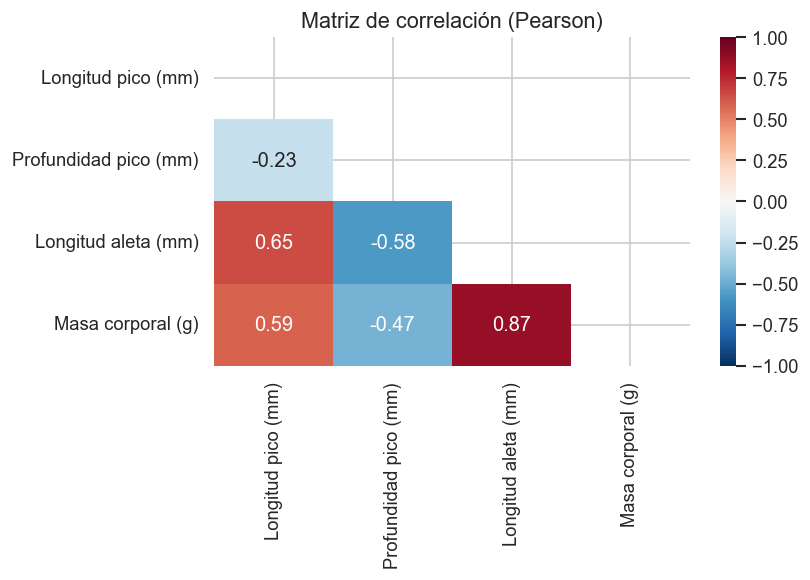

In [137]:
corr = df_clean[numericas].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            mask=mask, ax=ax,
            xticklabels=etiquetas, yticklabels=etiquetas)

ax.set_title('Matriz de correlación (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

**Hallazgos:**
- La **longitud de aleta** y la **masa corporal** tienen la correlación más alta (0.87): pingüinos más grandes tienen aletas más largas.
- La **profundidad del pico** correlaciona negativamente con la longitud de la aleta y la masa corporal, lo que podría deberse a diferencias morfológicas entre especies.

> **Nota:** Correlación no implica causalidad. El signo negativo en la profundidad del pico puede ser un efecto de la mezcla de especies (*Simpson's Paradox*).

### 4.2 Distribuciones por especie

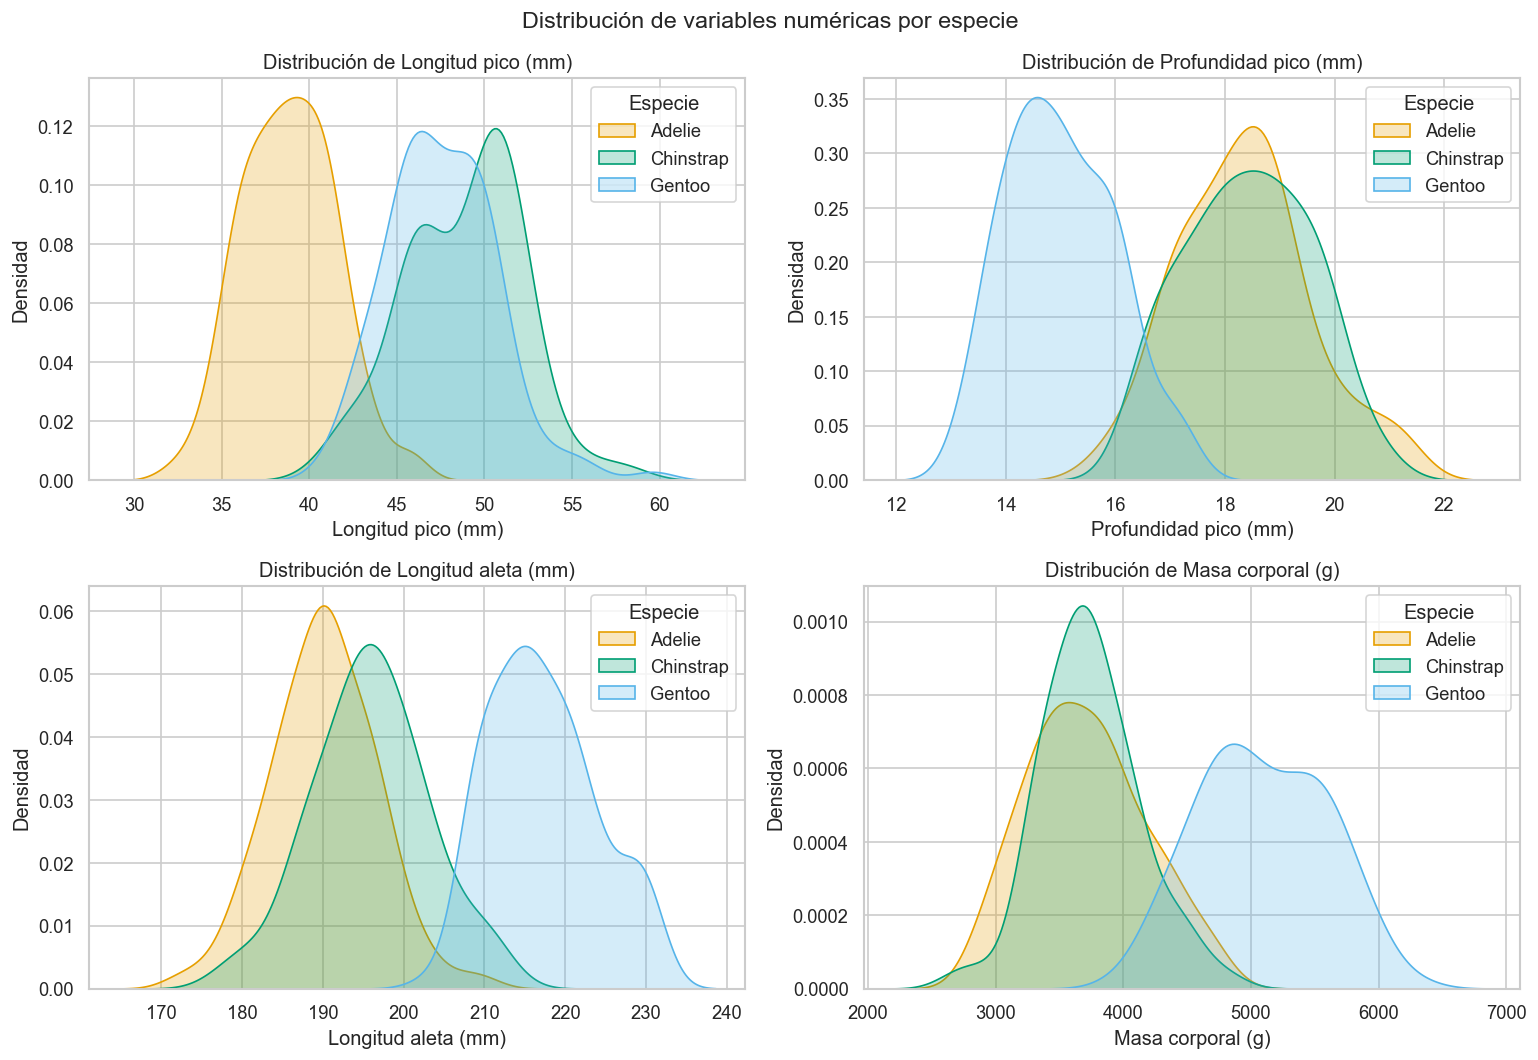

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col, etiqueta in zip(axes.flat, numericas, etiquetas):
    for especie, color in COLORES_ESPECIE.items():
        datos = df_clean.loc[df_clean['species'] == especie, col]
        sns.kdeplot(datos, ax=ax, label=especie, color=color, fill=True, alpha=0.25)
    ax.set_xlabel(etiqueta)
    ax.set_ylabel('Densidad')
    ax.set_title(f'Distribución de {etiqueta}')
    ax.legend(title='Especie')

fig.suptitle('Distribución de variables numéricas por especie', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgos:**
- **Gentoo** tiene las aletas más largas y mayor masa corporal, claramente separada de las otras dos especies.
- **Adelie** y **Chinstrap** son similares en longitud de aleta y masa, pero difieren en la **longitud del pico** (Chinstrap la tiene mayor).
- La **profundidad del pico** es lo que más distingue a Adelie de Chinstrap.

### 4.3 Boxplots por especie

C:\Users\eajae\AppData\Local\Temp\ipykernel_31584\3530709420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='species', y=col, ax=ax,
C:\Users\eajae\AppData\Local\Temp\ipykernel_31584\3530709420.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_clean, x='species', y=col, ax=ax,
C:\Users\eajae\AppData\Local\Temp\ipykernel_31584\3530709420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='species', y=col, ax=ax,
C:\Users\eajae\AppData\Local\Temp\ipykernel_31584\3530709420.py:7: FutureWarning

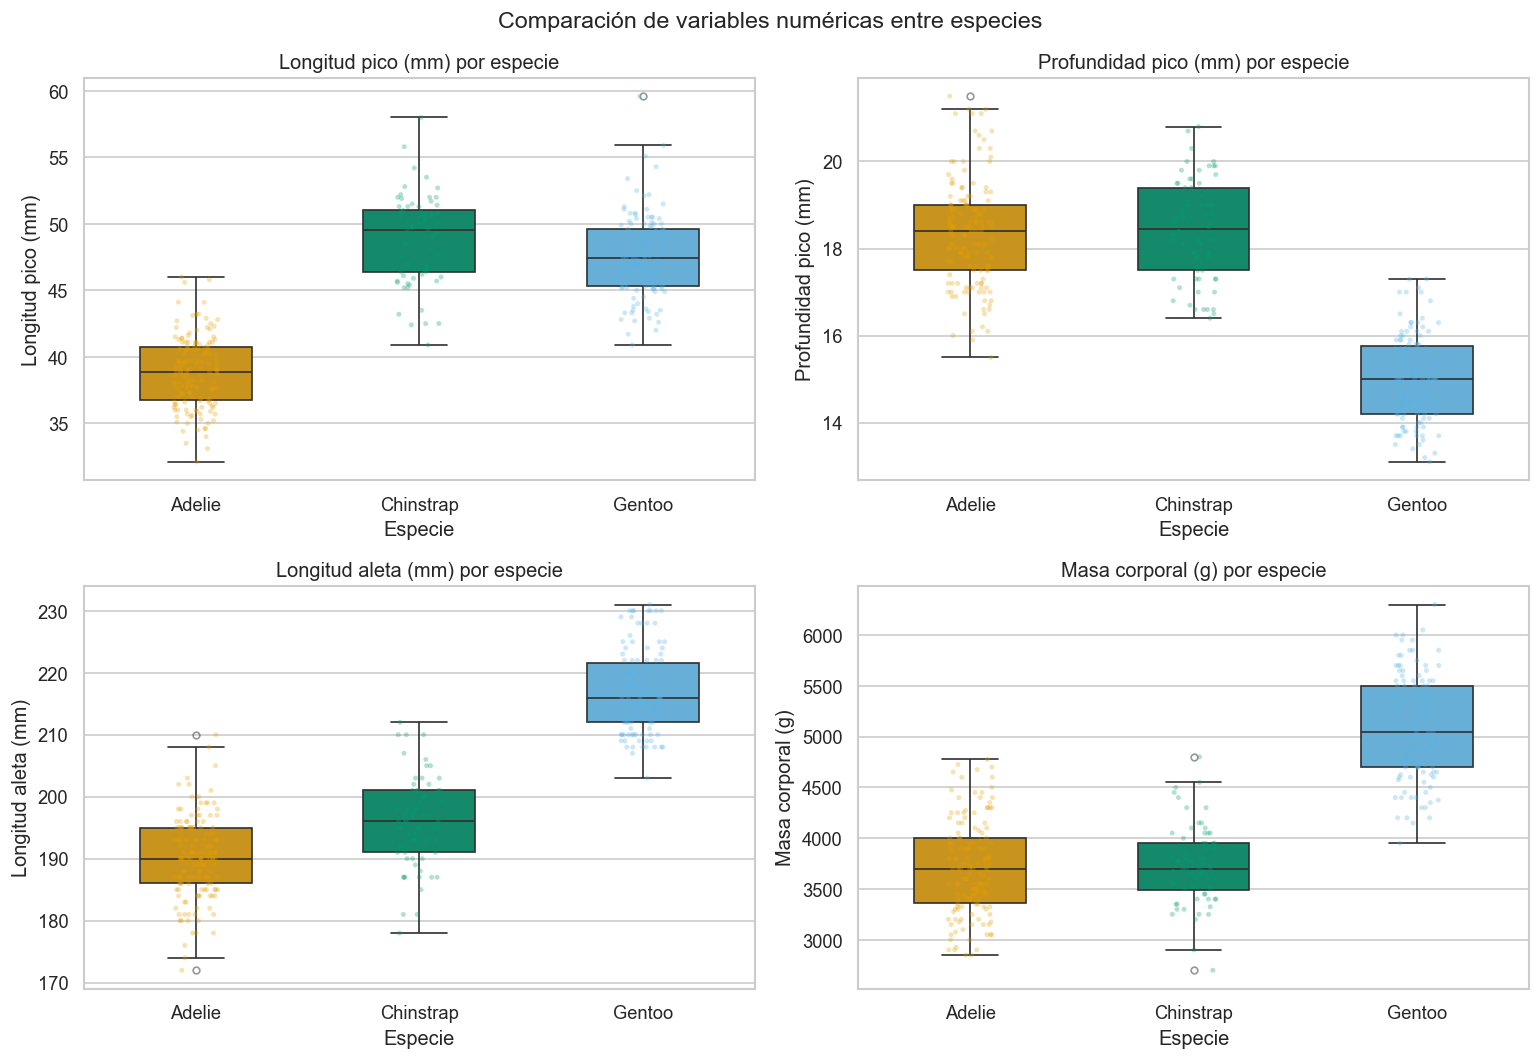

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col, etiqueta in zip(axes.flat, numericas, etiquetas):
    sns.boxplot(data=df_clean, x='species', y=col, ax=ax,
                palette=COLORES_ESPECIE, width=0.5,
                flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
    sns.stripplot(data=df_clean, x='species', y=col, ax=ax,
                  palette=COLORES_ESPECIE, size=3, alpha=0.3, jitter=True)
    ax.set_xlabel('Especie')
    ax.set_ylabel(etiqueta)
    ax.set_title(f'{etiqueta} por especie')

fig.suptitle('Comparación de variables numéricas entre especies', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Relación entre pico y especie

Las dimensiones del pico son clave en taxonomía de aves. Analicemos si permiten distinguir especies.

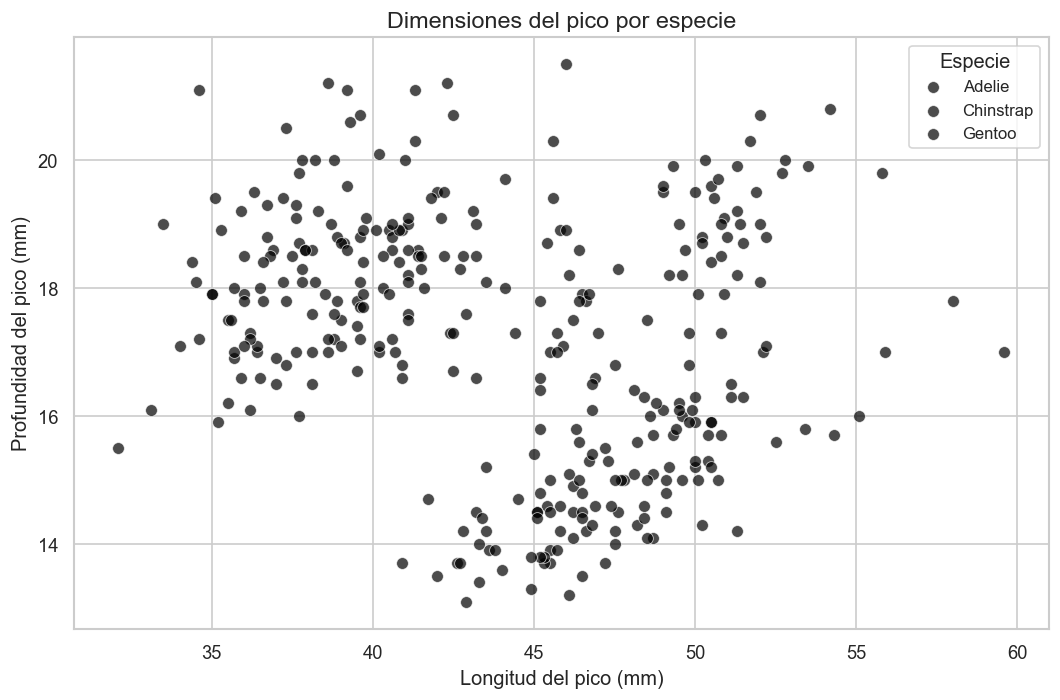

In [140]:
fig, ax = plt.subplots(figsize=(9, 6))

for especie, color in COLORES_ESPECIE.items():
    sub = df_clean[df_clean['species'] == especie]
    ax.scatter(sub['bill_length_mm'], sub['bill_depth_mm'],
               label=especie, color='black', alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Longitud del pico (mm)', fontsize=12)
ax.set_ylabel('Profundidad del pico (mm)', fontsize=12)
ax.set_title('Dimensiones del pico por especie', fontsize=14)
ax.legend(title='Especie', fontsize=10)

plt.tight_layout()
plt.show()

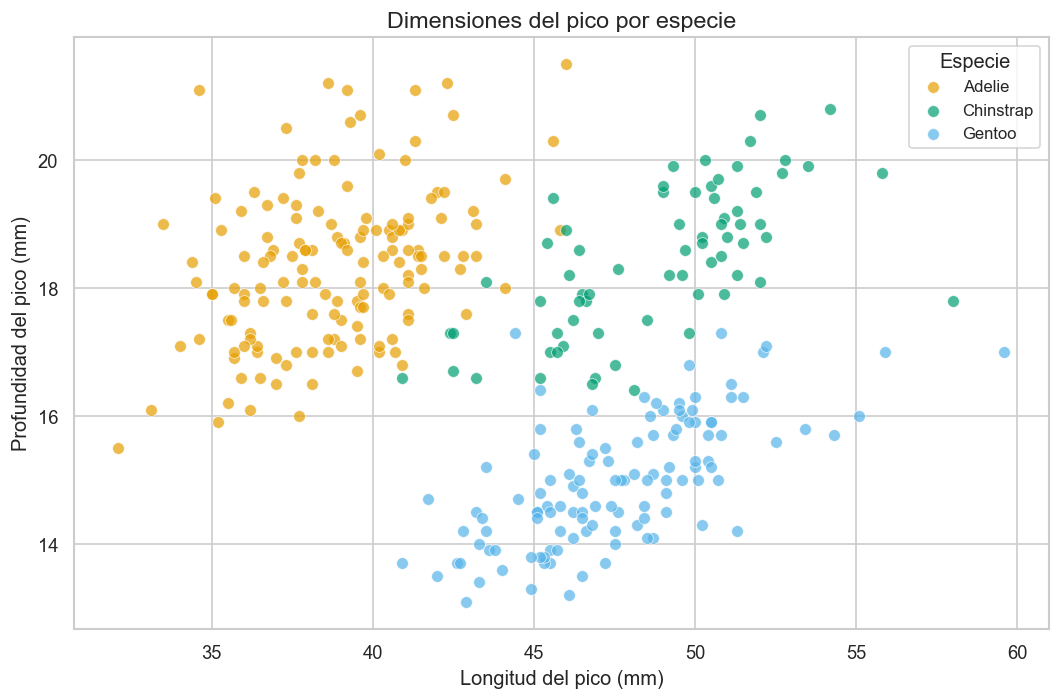

In [141]:
fig, ax = plt.subplots(figsize=(9, 6))

for especie, color in COLORES_ESPECIE.items():
    sub = df_clean[df_clean['species'] == especie]
    ax.scatter(sub['bill_length_mm'], sub['bill_depth_mm'],
               label=especie, color=color, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Longitud del pico (mm)', fontsize=12)
ax.set_ylabel('Profundidad del pico (mm)', fontsize=12)
ax.set_title('Dimensiones del pico por especie', fontsize=14)
ax.legend(title='Especie', fontsize=10)

plt.tight_layout()
plt.show()

Este gráfico ilustra el concepto de **Paradoja de Simpson**: usando solo la longitud del pico, la correlación con profundidad parece negativa (mezcla de especies). Al separar por especie, vemos que la correlación es positiva dentro de cada grupo.

### 4.5 Variables categóricas cruzadas

In [142]:
# Tabla cruzada especie × isla
tabla = pd.crosstab(df_clean['species'], df_clean['island'])
print('Distribución de especies por isla:')
print(tabla)

Distribución de especies por isla:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0


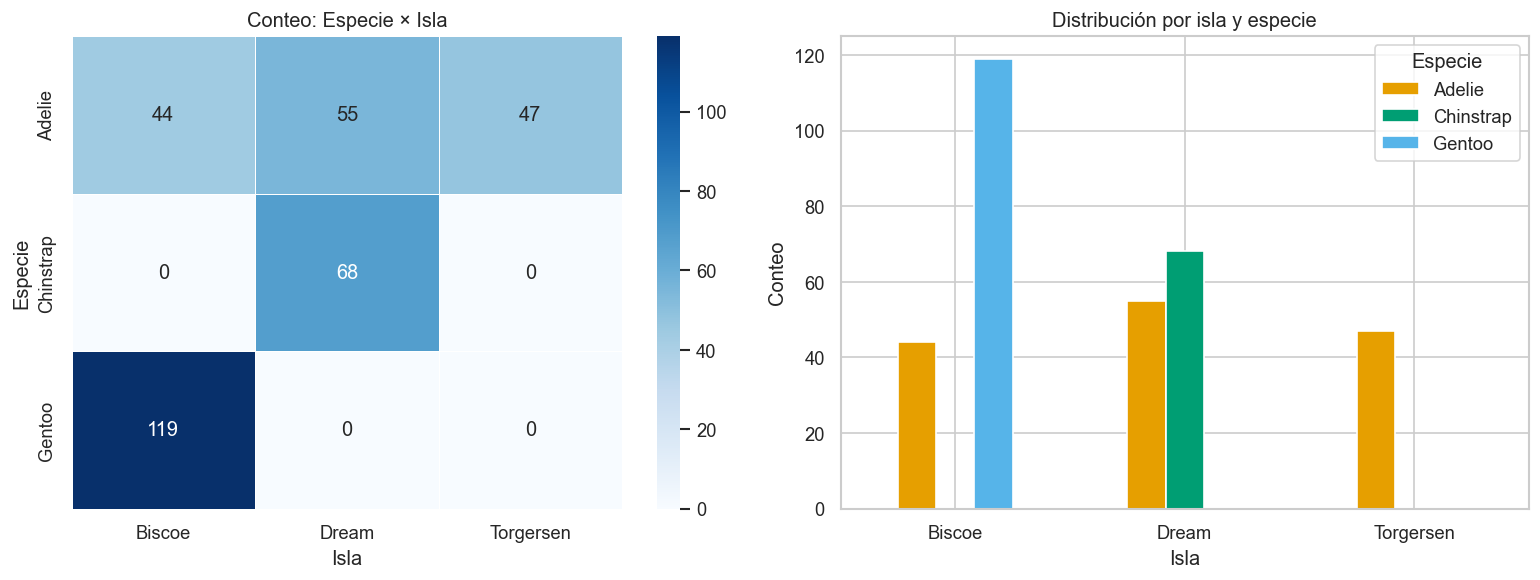

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap de conteos
sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Conteo: Especie × Isla', fontsize=12)
axes[0].set_xlabel('Isla')
axes[0].set_ylabel('Especie')

# Barras agrupadas
tabla.T.plot(kind='bar', ax=axes[1],
             color=list(COLORES_ESPECIE.values()),
             edgecolor='white', rot=0)
axes[1].set_title('Distribución por isla y especie', fontsize=12)
axes[1].set_xlabel('Isla')
axes[1].set_ylabel('Conteo')
axes[1].legend(title='Especie')

plt.tight_layout()
plt.show()

**Hallazgo importante:**
- **Gentoo** habita exclusivamente en Biscoe.
- **Chinstrap** habita exclusivamente en Dream.
- **Adelie** es la única especie presente en las tres islas.

Esto significa que la isla es un predictor casi perfecto para Gentoo y Chinstrap.

## 5. Análisis multivariado

### 5.1 Pair plot: todas las variables numéricas por especie

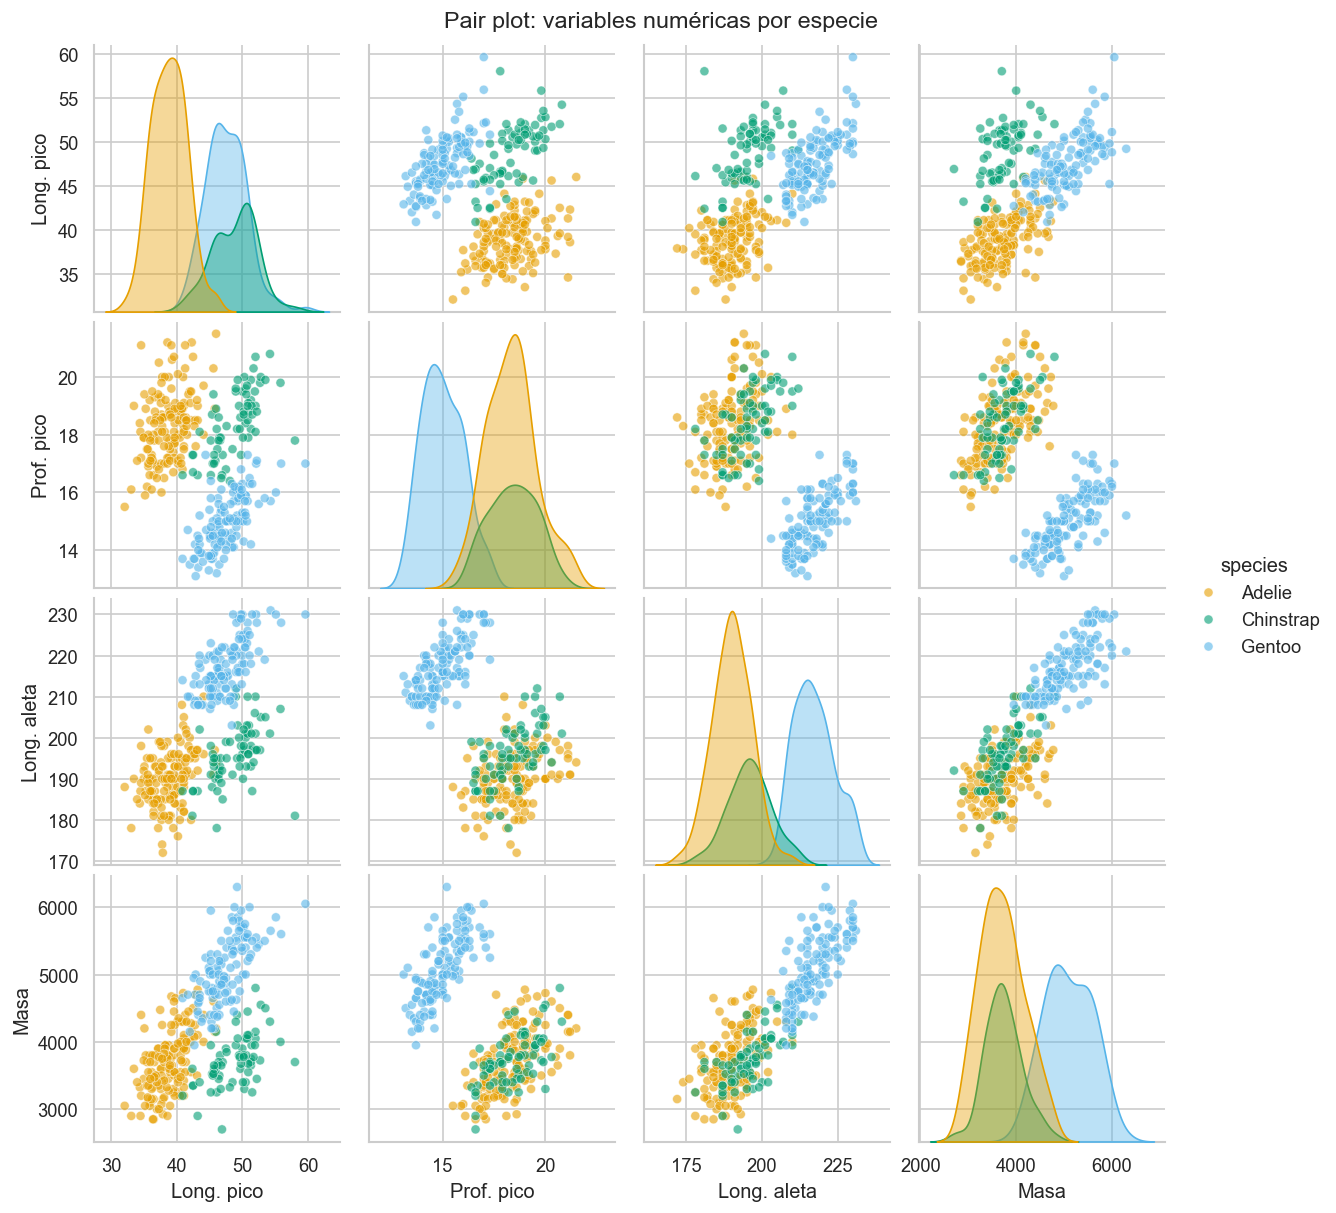

In [144]:
g = sns.pairplot(
    df_clean,
    vars=numericas,
    hue='species',
    palette=COLORES_ESPECIE,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kws={'fill': True, 'alpha': 0.4}
)

# Renombrar ejes
etiquetas_cortas = ['Long. pico', 'Prof. pico', 'Long. aleta', 'Masa']
for ax, etq in zip(g.axes[-1], etiquetas_cortas):
    ax.set_xlabel(etq)
for ax, etq in zip(g.axes[:, 0], etiquetas_cortas):
    ax.set_ylabel(etq)

g.figure.suptitle('Pair plot: variables numéricas por especie', y=1.01, fontsize=14)
plt.show()

### 5.2 Efecto del sexo dentro de cada especie

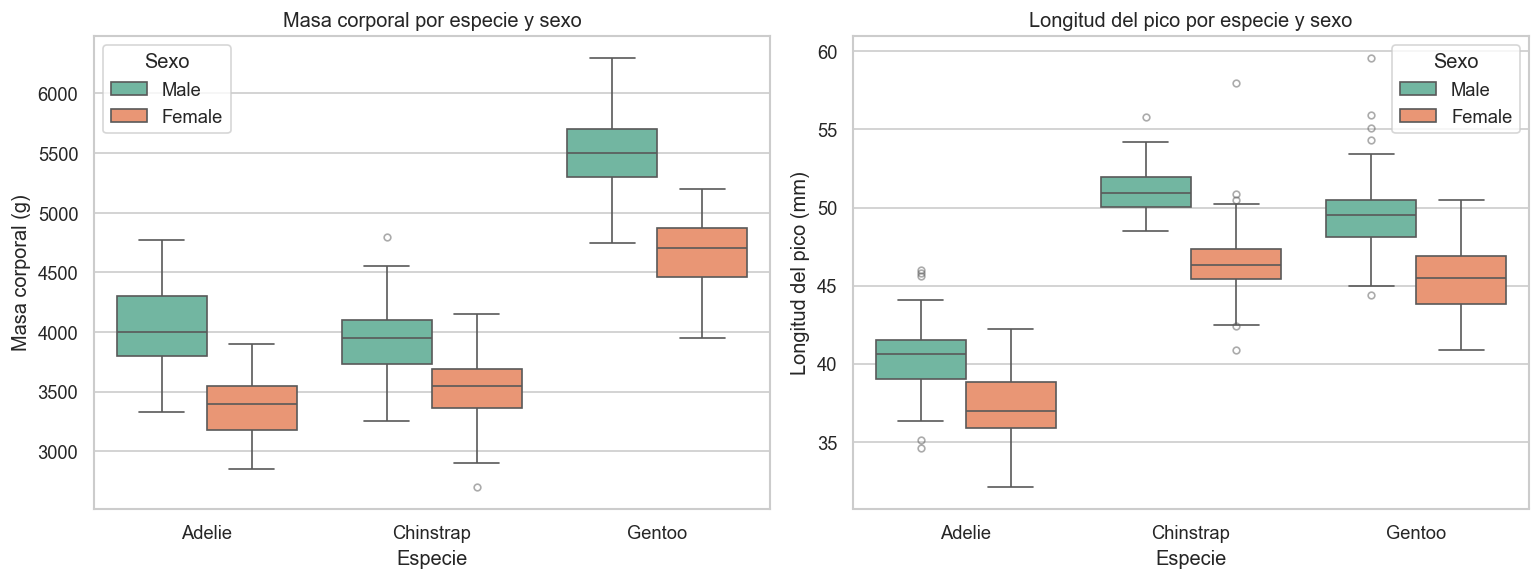

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Masa corporal por especie y sexo
sns.boxplot(data=df_clean, x='species', y='body_mass_g',
            hue='sex', palette='Set2', ax=axes[0],
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
axes[0].set_title('Masa corporal por especie y sexo')
axes[0].set_xlabel('Especie')
axes[0].set_ylabel('Masa corporal (g)')
axes[0].legend(title='Sexo')

# Longitud pico por especie y sexo
sns.boxplot(data=df_clean, x='species', y='bill_length_mm',
            hue='sex', palette='Set2', ax=axes[1],
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
axes[1].set_title('Longitud del pico por especie y sexo')
axes[1].set_xlabel('Especie')
axes[1].set_ylabel('Longitud del pico (mm)')
axes[1].legend(title='Sexo')

plt.tight_layout()
plt.show()

### 5.3 Resumen estadístico por especie

In [146]:
resumen = df_clean.groupby('species')[numericas].agg(['mean', 'std']).round(2)
resumen.columns = ['_'.join(col) for col in resumen.columns]
resumen

,bill_length_mm_mean,bill_length_mm_std,bill_depth_mm_mean,bill_depth_mm_std,flipper_length_mm_mean,flipper_length_mm_std,body_mass_g_mean,body_mass_g_std
species,,,,,,,,
Adelie,38.82,2.66,18.35,1.22,190.10,6.52,3706.16,458.62
Chinstrap,48.83,3.34,18.42,1.14,195.82,7.13,3733.09,384.34
Gentoo,47.57,3.11,15.00,0.99,217.24,6.59,5092.44,501.48


### 5.4 Radar chart: perfil morfológico promedio por especie

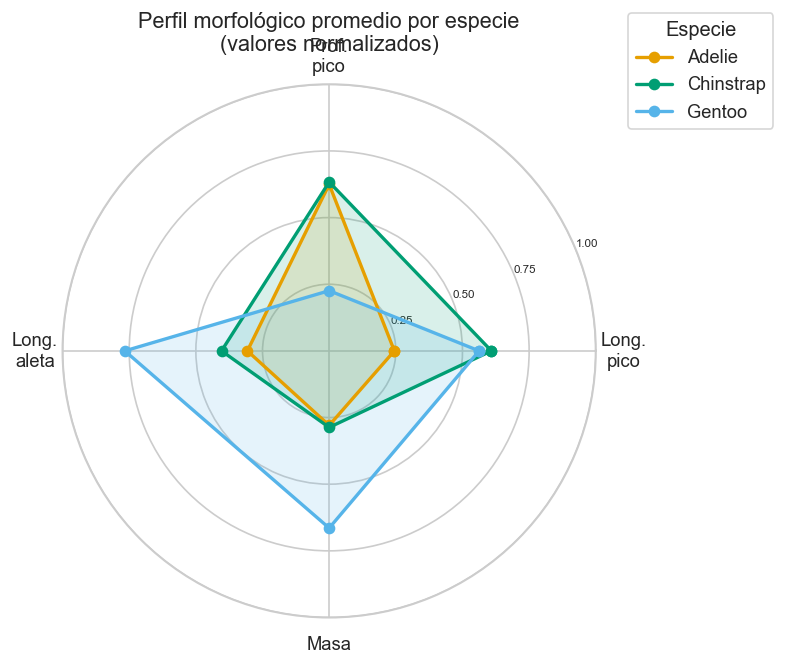

In [147]:
from matplotlib.patches import FancyArrowPatch

# Normalizar variables entre 0 y 1 para comparar en la misma escala
df_norm = df_clean.copy()
for col in numericas:
    mn, mx = df_clean[col].min(), df_clean[col].max()
    df_norm[col] = (df_clean[col] - mn) / (mx - mn)

medias = df_norm.groupby('species')[numericas].mean()

# Configuración del radar
categorias_radar = ['Long.\npico', 'Prof.\npico', 'Long.\naleta', 'Masa']
N = len(categorias_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for especie, color in COLORES_ESPECIE.items():
    valores = medias.loc[especie].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2, label=especie, color=color)
    ax.fill(angulos, valores, alpha=0.15, color=color)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias_radar, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
ax.set_title('Perfil morfológico promedio por especie\n(valores normalizados)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), title='Especie')

plt.tight_layout()
plt.show()

## 6. Clasificación: regresión logística multinomial

Predecimos la **especie** a partir de tres variables: longitud de aleta (`flipper_length_mm`), masa corporal (`body_mass_g`) y sexo.

La **regresión logística multinomial** no modela la probabilidad en crudo, sino el **logaritmo de los momios** (log-odds) respecto a una clase de referencia. Tomamos **Adelie** como referencia:

$$
\log\left(\frac{P(Y = k)}{P(Y = \text{Adelie})}\right)
= \beta_{k0} + \beta_{k1}\,\text{flipper\_length} + \beta_{k2}\,\text{body\_mass} + \beta_{k3}\,\text{sex\_Male}
$$

para $k \in \{\text{Chinstrap},\, \text{Gentoo}\}$. El sexo entra como dummy: `sex_Male = 1` si es macho y `0` si es hembra.

La probabilidad de cada especie se recupera con la función softmax:

$$
P(Y = k \mid \mathbf{x})
= \frac{e^{\eta_k}}{e^{\eta_{\text{Adelie}}} + e^{\eta_{\text{Chinstrap}}} + e^{\eta_{\text{Gentoo}}}}
$$

donde $\eta_{\text{Adelie}} = 0$ y $\eta_k$ es el lado derecho de la ecuación de log-odds.

### 6.1 Preparación de datos y ajuste

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Predictoras: aleta, masa y sexo (dummy: sex_Male)
predictores = ['flipper_length_mm', 'body_mass_g', 'sex']
X = pd.get_dummies(df_clean[predictores], drop_first=True, dtype=int)
y = df_clean['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Entrenamiento: {len(X_train)}  |  Prueba: {len(X_test)}')
print('Columnas de X:', list(X.columns))
X.head()

Entrenamiento: 266  |  Prueba: 67
Columnas de X: ['flipper_length_mm', 'body_mass_g', 'sex_Male']


,flipper_length_mm,body_mass_g,sex_Male
0,181.0,3750.0,1
1,186.0,3800.0,0
2,195.0,3250.0,0
3,193.0,3450.0,0
4,190.0,3650.0,1


In [149]:
# Logística multinomial (softmax). sklearn usa regularización L2 por defecto.
modelo = LogisticRegression(solver='lbfgs', max_iter=2000)
modelo.fit(X_train, y_train)

coeficientes = pd.DataFrame(
    modelo.coef_,
    index=modelo.classes_,
    columns=X.columns,
)
coeficientes['intercepto'] = modelo.intercept_

print('Coeficientes softmax por especie:')
coeficientes.round(4)

Coeficientes softmax por especie:


,flipper_length_mm,body_mass_g,sex_Male,intercepto
Adelie,-0.2406,-0.0006,1.0559,51.6533
Chinstrap,-0.0933,-0.0015,0.8835,25.6071
Gentoo,0.3339,0.0021,-1.9394,-77.2604


### 6.2 Ecuación estimada

Restamos los coeficientes de Adelie para escribir el modelo en la forma de log-odds respecto a la referencia. El resultado es exactamente:

$$
\log\left(\frac{P(Y = k)}{P(Y = \text{Adelie})}\right)
= \hat\beta_{k0} + \hat\beta_{k1}\,\text{flipper\_length} + \hat\beta_{k2}\,\text{body\_mass} + \hat\beta_{k3}\,\text{sex\_Male}
$$

In [150]:
# Log-odds respecto a Adelie: eta_k - eta_Adelie
ref = 'Adelie'
i_ref = list(modelo.classes_).index(ref)
nombres = list(X.columns)

print(f'Clase de referencia: {ref}\n')
for i, clase in enumerate(modelo.classes_):
    if clase == ref:
        continue
    b0 = modelo.intercept_[i] - modelo.intercept_[i_ref]
    betas = modelo.coef_[i] - modelo.coef_[i_ref]
    partes = [f'{b0:.4f}'] + [f'{b:+.4f}·{nom}' for nom, b in zip(nombres, betas)]
    print(f'log(P({clase}) / P({ref})) = ' + ' '.join(partes))

Clase de referencia: Adelie

log(P(Chinstrap) / P(Adelie)) = -26.0463 +0.1473·flipper_length_mm -0.0008·body_mass_g -0.1724·sex_Male
log(P(Gentoo) / P(Adelie)) = -128.9138 +0.5746·flipper_length_mm +0.0028·body_mass_g -2.9953·sex_Male


### 6.3 Evaluación en el conjunto de prueba

Accuracy: 0.836

              precision    recall  f1-score   support

      Adelie       0.74      0.97      0.84        29
   Chinstrap       0.80      0.29      0.42        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.84        67
   macro avg       0.85      0.75      0.75        67
weighted avg       0.84      0.84      0.81        67



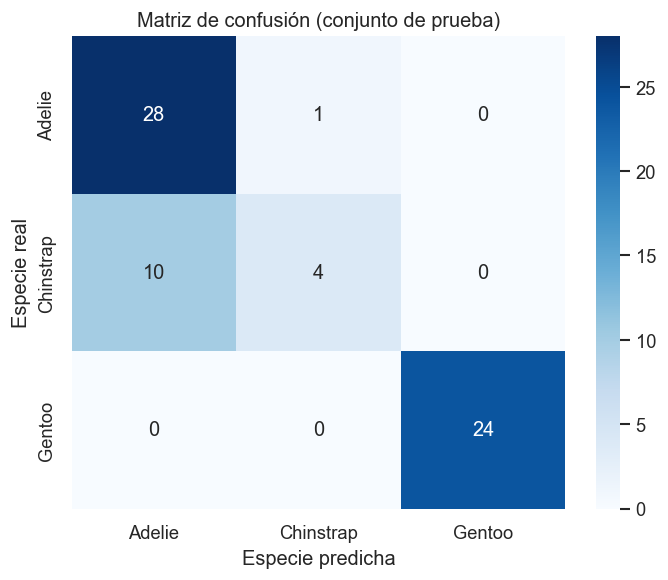

In [151]:
y_pred = modelo.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}\n')
print(classification_report(y_test, y_pred))

orden = ['Adelie', 'Chinstrap', 'Gentoo']
cm = confusion_matrix(y_test, y_pred, labels=orden)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=orden, yticklabels=orden, ax=ax,
)
ax.set_xlabel('Especie predicha')
ax.set_ylabel('Especie real')
ax.set_title('Matriz de confusión (conjunto de prueba)')
plt.tight_layout()
plt.show()

In [152]:
# Clasificar e imprimir los primeros 5 del conjunto de prueba
muestra = X_test.head(5).copy()
probs = modelo.predict_proba(muestra)
pred = modelo.predict(muestra)

tabla = muestra.copy()
tabla.insert(0, 'especie_real', y_test.loc[muestra.index].values)
tabla['especie_predicha'] = pred
for i, clase in enumerate(modelo.classes_):
    tabla[f'P({clase})'] = probs[:, i].round(3)

print('Clasificación de los primeros 5 del conjunto de prueba:')
tabla

Clasificación de los primeros 5 del conjunto de prueba:


,especie_real,flipper_length_mm,body_mass_g,sex_Male,especie_predicha,P(Adelie),P(Chinstrap),P(Gentoo)
321,Gentoo,216.0,5000.0,0,Gentoo,0.000,0.001,0.999
208,Chinstrap,195.0,3650.0,0,Adelie,0.588,0.412,0.001
87,Adelie,186.0,4450.0,1,Adelie,0.925,0.075,0.000
300,Gentoo,212.0,4875.0,0,Gentoo,0.002,0.005,0.993
282,Gentoo,216.0,4750.0,0,Gentoo,0.000,0.001,0.998


In [153]:
# Filtrar los del test donde el modelo no acertó
probs_test = modelo.predict_proba(X_test)

fallos = X_test.copy()
fallos.insert(0, 'especie_real', y_test.loc[X_test.index].values)
fallos['especie_predicha'] = y_pred
for i, clase in enumerate(modelo.classes_):
    fallos[f'P({clase})'] = probs_test[:, i].round(3)

fallos = fallos.loc[fallos['especie_real'] != fallos['especie_predicha']]

print(f'No acertó en {len(fallos)} de {len(X_test)} casos de prueba')
fallos

No acertó en 11 de 67 casos de prueba


,especie_real,flipper_length_mm,body_mass_g,sex_Male,especie_predicha,P(Adelie),P(Chinstrap),P(Gentoo)
208,Chinstrap,195.0,3650.0,0,Adelie,0.588,0.412,0.001
177,Chinstrap,201.0,4300.0,1,Adelie,0.543,0.451,0.006
188,Chinstrap,196.0,3550.0,1,Adelie,0.574,0.426,0.000
168,Chinstrap,187.0,2900.0,0,Adelie,0.713,0.287,0.000
187,Chinstrap,187.0,3650.0,0,Adelie,0.823,0.177,0.000
184,Chinstrap,192.0,2700.0,0,Adelie,0.502,0.498,0.000
190,Chinstrap,196.0,3675.0,0,Adelie,0.556,0.442,0.001
149,Chinstrap,188.0,3525.0,0,Adelie,0.783,0.217,0.000
160,Chinstrap,190.0,3575.0,0,Adelie,0.737,0.263,0.000
145,Adelie,201.0,4000.0,1,Chinstrap,0.483,0.515,0.002


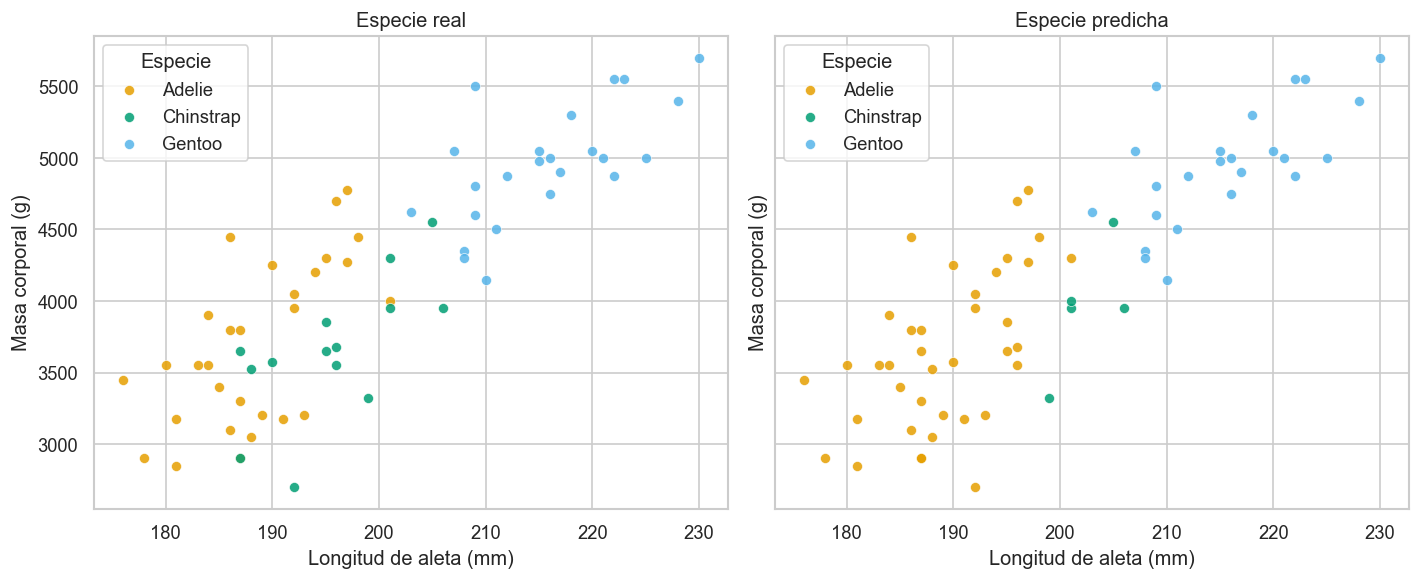

In [154]:
# Comparar especie real vs predicha en el plano aleta–masa
comparacion = X_test.copy()
comparacion['real'] = y_test.values
comparacion['predicha'] = y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, col, titulo in zip(
    axes,
    ['real', 'predicha'],
    ['Especie real', 'Especie predicha'],
):
    for especie, color in COLORES_ESPECIE.items():
        sub = comparacion[comparacion[col] == especie]
        ax.scatter(
            sub['flipper_length_mm'], sub['body_mass_g'],
            c=color, label=especie, alpha=0.85,
            edgecolors='white', linewidths=0.4,
        )
    ax.set_xlabel('Longitud de aleta (mm)')
    ax.set_ylabel('Masa corporal (g)')
    ax.set_title(titulo)
    ax.legend(title='Especie')

plt.tight_layout()
plt.show()

**Hallazgos:**
- **Gentoo** se clasifica casi sin error: aletas más largas y mayor masa corporal lo separan del resto.
- **Chinstrap** se confunde con **Adelie**: en aleta y masa se solapan; lo que las distingue en el EDA era la **longitud del pico**, que no entra en este modelo.
- El coeficiente de `flipper_length_mm` es el más útil para subir las log-odds de Gentoo frente a Adelie. El de `body_mass_g` se ve pequeño porque está en gramos.
- `sex_Male` captura el dimorfismo (los machos son más grandes), pero por sí solo no separa especies.

## 7. Clasificación incluyendo la longitud del pico

El modelo anterior fallaba sobre todo en **Chinstrap vs Adelie**. En el EDA vimos que lo que las separa es la **longitud del pico**. Repetimos la logística multinomial con las mismas observaciones de entrenamiento/prueba, ahora con:

`bill_length_mm`, `flipper_length_mm`, `body_mass_g` y `sex`.

Con Adelie como referencia:

$$
\log\left(\frac{P(Y = k)}{P(Y = \text{Adelie})}\right)
= \beta_{k0} + \beta_{k1}\,\text{bill\_length} + \beta_{k2}\,\text{flipper\_length} + \beta_{k3}\,\text{body\_mass} + \beta_{k4}\,\text{sex\_Male}
$$

para $k \in \{\text{Chinstrap},\, \text{Gentoo}\}$. La probabilidad sigue saliendo del softmax.

### 7.1 Preparación de datos y ajuste

In [155]:
# Mismo split (random_state=42) para comparar con el modelo anterior
predictores2 = ['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
X2 = pd.get_dummies(df_clean[predictores2], drop_first=True, dtype=int)
y2 = df_clean['species']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)

print(f'Entrenamiento: {len(X2_train)}  |  Prueba: {len(X2_test)}')
print('Columnas de X:', list(X2.columns))
X2.head()

Entrenamiento: 266  |  Prueba: 67
Columnas de X: ['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'sex_Male']


,bill_length_mm,flipper_length_mm,body_mass_g,sex_Male
0,39.1,181.0,3750.0,1
1,39.5,186.0,3800.0,0
2,40.3,195.0,3250.0,0
3,36.7,193.0,3450.0,0
4,39.3,190.0,3650.0,1


In [156]:
modelo2 = LogisticRegression(solver='lbfgs', max_iter=8000)
modelo2.fit(X2_train, y2_train)

coeficientes2 = pd.DataFrame(
    modelo2.coef_,
    index=modelo2.classes_,
    columns=X2.columns,
)
coeficientes2['intercepto'] = modelo2.intercept_

print('Coeficientes softmax por especie:')
coeficientes2.round(4)

Coeficientes softmax por especie:


,bill_length_mm,flipper_length_mm,body_mass_g,sex_Male,intercepto
Adelie,-0.8806,-0.1120,0.0015,1.5344,56.2616
Chinstrap,1.3780,-0.2215,-0.0066,-0.3749,9.8193
Gentoo,-0.4974,0.3335,0.0051,-1.1595,-66.0808


### 7.2 Ecuación estimada

Restamos los coeficientes de Adelie para escribir el log-odds respecto a la referencia:

$$
\log\left(\frac{P(Y = k)}{P(Y = \text{Adelie})}\right)
= \hat\beta_{k0} + \hat\beta_{k1}\,\text{bill\_length} + \hat\beta_{k2}\,\text{flipper\_length} + \hat\beta_{k3}\,\text{body\_mass} + \hat\beta_{k4}\,\text{sex\_Male}
$$

In [157]:
ref = 'Adelie'
i_ref = list(modelo2.classes_).index(ref)
nombres = list(X2.columns)

print(f'Clase de referencia: {ref}\n')
for i, clase in enumerate(modelo2.classes_):
    if clase == ref:
        continue
    b0 = modelo2.intercept_[i] - modelo2.intercept_[i_ref]
    betas = modelo2.coef_[i] - modelo2.coef_[i_ref]
    partes = [f'{b0:.4f}'] + [f'{b:+.4f}·{nom}' for nom, b in zip(nombres, betas)]
    print(f'log(P({clase}) / P({ref})) = ' + ' '.join(partes))

Clase de referencia: Adelie

log(P(Chinstrap) / P(Adelie)) = -46.4423 +2.2587·bill_length_mm -0.1096·flipper_length_mm -0.0081·body_mass_g -1.9093·sex_Male
log(P(Gentoo) / P(Adelie)) = -122.3424 +0.3832·bill_length_mm +0.4455·flipper_length_mm +0.0035·body_mass_g -2.6939·sex_Male


### 7.3 Evaluación en el conjunto de prueba

Accuracy: 0.955
(Modelo sin pico: 0.836)

              precision    recall  f1-score   support

      Adelie       1.00      0.93      0.96        29
   Chinstrap       0.82      1.00      0.90        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.96        67
   macro avg       0.94      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



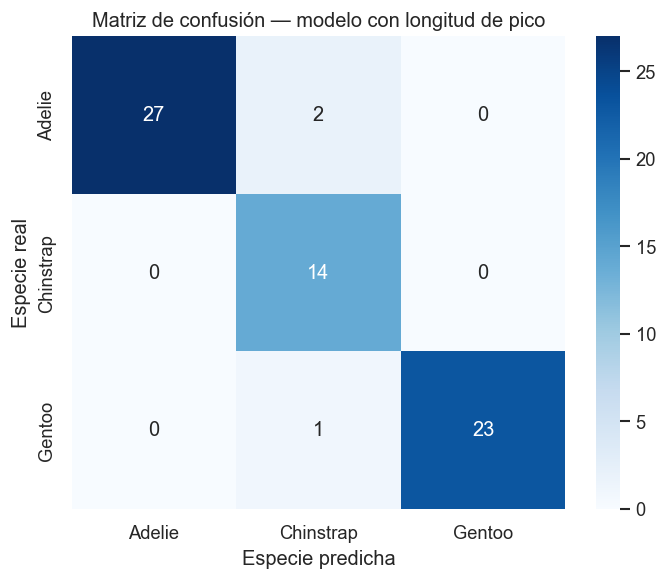

In [158]:
y2_pred = modelo2.predict(X2_test)

print(f'Accuracy: {accuracy_score(y2_test, y2_pred):.3f}')
print(f'(Modelo sin pico: {accuracy_score(y_test, y_pred):.3f})\n')
print(classification_report(y2_test, y2_pred))

orden = ['Adelie', 'Chinstrap', 'Gentoo']
cm2 = confusion_matrix(y2_test, y2_pred, labels=orden)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Blues',
    xticklabels=orden, yticklabels=orden, ax=ax,
)
ax.set_xlabel('Especie predicha')
ax.set_ylabel('Especie real')
ax.set_title('Matriz de confusión — modelo con longitud de pico')
plt.tight_layout()
plt.show()

In [159]:
# Clasificar e imprimir los primeros 5 del conjunto de prueba
muestra2 = X2_test.head(5).copy()
probs2 = modelo2.predict_proba(muestra2)
pred2 = modelo2.predict(muestra2)

tabla2 = muestra2.copy()
tabla2.insert(0, 'especie_real', y2_test.loc[muestra2.index].values)
tabla2['especie_predicha'] = pred2
for i, clase in enumerate(modelo2.classes_):
    tabla2[f'P({clase})'] = probs2[:, i].round(3)

print('Clasificación de los primeros 5 del conjunto de prueba:')
tabla2

Clasificación de los primeros 5 del conjunto de prueba:


,especie_real,bill_length_mm,flipper_length_mm,body_mass_g,sex_Male,especie_predicha,P(Adelie),P(Chinstrap),P(Gentoo)
321,Gentoo,50.5,216.0,5000.0,0,Gentoo,0.000,0.001,0.999
208,Chinstrap,45.7,195.0,3650.0,0,Chinstrap,0.003,0.997,0.000
87,Adelie,39.6,186.0,4450.0,1,Adelie,1.000,0.000,0.000
300,Gentoo,47.5,212.0,4875.0,0,Gentoo,0.001,0.000,0.999
282,Gentoo,47.7,216.0,4750.0,0,Gentoo,0.000,0.000,1.000


In [160]:
# Filtrar los del test donde el modelo con pico no acertó
probs2_test = modelo2.predict_proba(X2_test)

fallos2 = X2_test.copy()
fallos2.insert(0, 'especie_real', y2_test.loc[X2_test.index].values)
fallos2['especie_predicha'] = y2_pred
for i, clase in enumerate(modelo2.classes_):
    fallos2[f'P({clase})'] = probs2_test[:, i].round(3)

fallos2 = fallos2.loc[fallos2['especie_real'] != fallos2['especie_predicha']]

print(
    f'No acertó en {len(fallos2)} de {len(X2_test)} casos '
    f'(modelo sin pico: {len(fallos)} de {len(X_test)})'
)
fallos2

No acertó en 3 de 67 casos (modelo sin pico: 11 de 67)


,especie_real,bill_length_mm,flipper_length_mm,body_mass_g,sex_Male,especie_predicha,P(Adelie),P(Chinstrap),P(Gentoo)
14,Adelie,46.0,194.0,4200.0,1,Chinstrap,0.461,0.538,0.001
32,Adelie,42.2,180.0,3550.0,0,Chinstrap,0.426,0.574,0.000
310,Gentoo,48.4,203.0,4625.0,0,Chinstrap,0.025,0.521,0.454


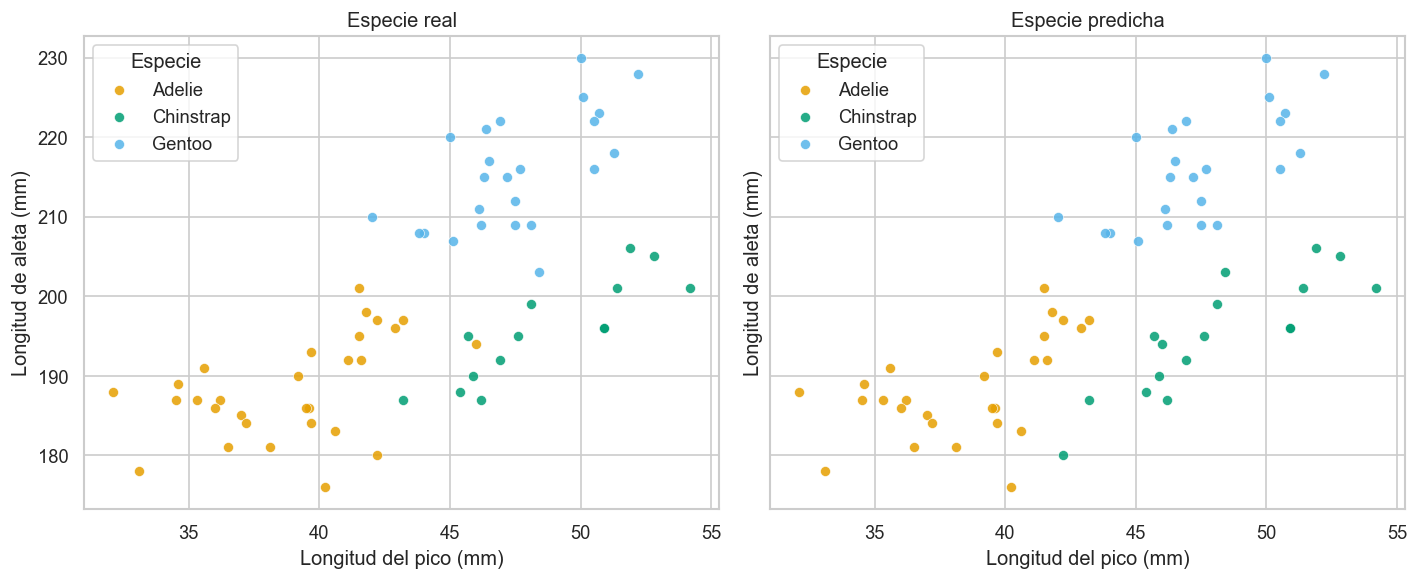

In [161]:
# Comparar especie real vs predicha en el plano pico–aleta
comparacion2 = X2_test.copy()
comparacion2['real'] = y2_test.values
comparacion2['predicha'] = y2_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, col, titulo in zip(
    axes,
    ['real', 'predicha'],
    ['Especie real', 'Especie predicha'],
):
    for especie, color in COLORES_ESPECIE.items():
        sub = comparacion2[comparacion2[col] == especie]
        ax.scatter(
            sub['bill_length_mm'], sub['flipper_length_mm'],
            c=color, label=especie, alpha=0.85,
            edgecolors='white', linewidths=0.4,
        )
    ax.set_xlabel('Longitud del pico (mm)')
    ax.set_ylabel('Longitud de aleta (mm)')
    ax.set_title(titulo)
    ax.legend(title='Especie')

plt.tight_layout()
plt.show()

**Hallazgos:**
- Añadir `bill_length_mm` sube el accuracy de ~84% a ~96% en el mismo conjunto de prueba.
- **Chinstrap** deja de confundirse con Adelie: el pico largo empuja las log-odds hacia Chinstrap.
- **Gentoo** sigue bien separado por la aleta; el pico aporta poco extra para esa especie.
- Los pocos fallos que quedan son pingüinos con pico atípico para su especie (Adelie con pico largo o Gentoo con aleta más corta).

### 7.4 Comparación train vs test

Antes de confiar en las métricas, conviene verificar que **entrenamiento y prueba** tengan aproximadamente las mismas proporciones: de especie (`y`) y de las predictoras (`X`). Si el split está sesgado, un accuracy alto puede ser engañoso.

In [162]:
# Mismo split en ambos modelos (random_state=42, stratify por especie)
idx_train, idx_test = X_train.index, X_test.index
df_tr = df_clean.loc[idx_train]
df_te = df_clean.loc[idx_test]

especies = ['Adelie', 'Chinstrap', 'Gentoo']
comp_y = pd.DataFrame({
    'n_train': y_train.value_counts().reindex(especies, fill_value=0),
    '%_train': (y_train.value_counts(normalize=True) * 100).reindex(especies, fill_value=0),
    'n_test': y_test.value_counts().reindex(especies, fill_value=0),
    '%_test': (y_test.value_counts(normalize=True) * 100).reindex(especies, fill_value=0),
}).round(2)
comp_y['dif_% (test − train)'] = (comp_y['%_test'] - comp_y['%_train']).round(2)

print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')
print('\nProporción de especies (y_train vs y_test):')
comp_y

Train: 266  |  Test: 67

Proporción de especies (y_train vs y_test):


,n_train,%_train,n_test,%_test,dif_% (test − train)
species,,,,,
Adelie,117,43.98,29,43.28,-0.70
Chinstrap,54,20.30,14,20.90,0.60
Gentoo,95,35.71,24,35.82,0.11


In [163]:
# --- X: media (o % si es dummy) en train vs test ---
numericas_comp = ['bill_length_mm', 'flipper_length_mm', 'body_mass_g']

filas = []
for col in numericas_comp:
    m_tr, m_te = df_tr[col].mean(), df_te[col].mean()
    s_tr, s_te = df_tr[col].std(), df_te[col].std()
    filas.append({
        'variable': f'media {col}',
        'train': m_tr,
        'test': m_te,
        'dif (test − train)': m_te - m_tr,
        'dif %': 100 * (m_te - m_tr) / m_tr,
    })
    filas.append({
        'variable': f'desv. {col}',
        'train': s_tr,
        'test': s_te,
        'dif (test − train)': s_te - s_tr,
        'dif %': 100 * (s_te - s_tr) / s_tr,
    })

p_male_tr = 100 * (df_tr['sex'] == 'Male').mean()
p_male_te = 100 * (df_te['sex'] == 'Male').mean()
filas.append({
    'variable': '% Male',
    'train': p_male_tr,
    'test': p_male_te,
    'dif (test − train)': p_male_te - p_male_tr,
    'dif %': 100 * (p_male_te - p_male_tr) / p_male_tr,
})

comp_x = pd.DataFrame(filas).set_index('variable').round(2)

print('Predictoras (X_train vs X_test):')
comp_x

Predictoras (X_train vs X_test):


,train,test,dif (test − train),dif %
variable,,,,
media bill_length_mm,43.98,44.03,0.04,0.10
desv. bill_length_mm,5.48,5.45,-0.03,-0.60
media flipper_length_mm,201.30,199.64,-1.66,-0.82
desv. flipper_length_mm,14.04,13.94,-0.10,-0.72
media body_mass_g,4224.44,4138.06,-86.38,-2.04
desv. body_mass_g,810.44,786.30,-24.14,-2.98
% Male,52.26,43.28,-8.97,-17.17


**Cómo leer las tablas:** si `dif %` en especie y en las predictoras es pequeño (unos pocos puntos), el split está equilibrado. Eso es lo esperado aquí porque usamos `stratify=y`: train y test conservan la mezcla de Adelie / Chinstrap / Gentoo.

## 8. Conclusiones

El análisis exploratorio nos reveló los siguientes hallazgos clave:

### Estructura del dataset
- 344 registros, 11 con valores faltantes (< 3.5%).
- Tres especies con distribución desbalanceada: Adelie (≈44%), Gentoo (≈36%), Chinstrap (≈20%).

### Diferencias morfológicas entre especies

| Variable | Gentoo | Chinstrap | Adelie |
|---|---|---|---|
| Longitud pico | Media | Alta | Baja |
| Profundidad pico | Baja | Media | Alta |
| Longitud aleta | **Alta** | Media | Baja |
| Masa corporal | **Alta** | Media | Baja |

### Variables más discriminantes
1. **Longitud de aleta** y **masa corporal**: separan claramente a Gentoo del resto.
2. **Longitud del pico**: distingue Chinstrap de Adelie.
3. **Isla**: predictor casi perfecto para Gentoo (Biscoe) y Chinstrap (Dream).

### Clasificación logística multinomial
- Sin longitud de pico (aleta + masa + sexo): **Gentoo** se identifica casi a la perfección; **Chinstrap** se confunde con Adelie (~84%, 11 fallos).
- Con longitud de pico: Chinstrap se separa y el accuracy sube a ~96% (3 fallos).
- Confirma el EDA: el pico era la variable que faltaba para distinguir Adelie de Chinstrap.

### Implicaciones para modelos predictivos
- El dataset es **altamente separable** si se incluyen las variables correctas (pico + aleta).
- La **paradoja de Simpson** en la correlación pico-longitud/profundidad muestra la importancia de segmentar por grupos antes de interpretar correlaciones.
- El **dimorfismo sexual** es consistente: los machos son más grandes en todas las especies.